# K-Means

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

## California Housing

### Paso 1: Carga del conjunto de datos

Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.   
En este caso solo nos interesan las columnas `Latitude`, `Longitude` y `MedInc`.

In [2]:
df = pd.read_csv('../data/raw/housing.csv')
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.drop(['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal'], axis=1, inplace=True) 
df

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25
...,...,...,...
20635,1.5603,39.48,-121.09
20636,2.5568,39.49,-121.21
20637,1.7000,39.43,-121.22
20638,1.8672,39.43,-121.32


In [4]:
df.shape

(20640, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     20640 non-null  float64
 1   Latitude   20640 non-null  float64
 2   Longitude  20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100


In [7]:
df.duplicated().sum()

np.int64(5)

In [8]:
# To show all the duplicated raws 
duplicated = df[df.duplicated(keep=False)]
duplicated

,MedInc,Latitude,Longitude
4569,2.3438,34.07,-118.27
4571,2.3438,34.07,-118.27
4605,15.0001,34.07,-118.33
4606,15.0001,34.07,-118.33
5291,15.0001,34.08,-118.42
8852,15.0001,34.08,-118.42
8853,15.0001,34.07,-118.41
8854,15.0001,34.07,-118.41
16328,4.3008,38.02,-121.33
16331,4.3008,38.02,-121.33


In [9]:
# To modify deleting duplicated ones and create a new copy of data frame
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(20635, 3)

In [11]:
df.isnull().sum()

MedInc       0
Latitude     0
Longitude    0
dtype: int64

In [12]:
df[(df == 0).any(axis=1)]

,MedInc,Latitude,Longitude


In [13]:
# Perform train/test split before scaling
X_train, X_test = train_test_split(df, 
                                   test_size=0.2, 
                                   random_state=42)

In [14]:
X_train

,MedInc,Latitude,Longitude
19985,3.1453,36.20,-119.31
11235,5.2384,33.81,-117.96
2271,3.5542,36.78,-119.80
8660,4.3594,33.85,-118.39
6250,3.4722,34.04,-117.98
...,...,...,...
11288,5.2370,33.80,-117.95
11968,1.9052,34.00,-117.41
5392,3.1827,34.04,-118.37
860,5.7192,37.58,-121.96


#### Escalado - RobustScaler()

In [15]:
# Scale train and test
robust_scaler = RobustScaler()

X_train_scaled = robust_scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled,
                              columns=X_train.columns,
                              index=X_train.index)

X_test_scaled = robust_scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled,
                             columns=X_test.columns,
                             index=X_test.index)

X_train_scaled

,MedInc,Latitude,Longitude
19985,-0.176549,0.511873,-0.213158
11235,0.776105,-0.118734,0.142105
2271,0.009558,0.664908,-0.342105
8660,0.376037,-0.108179,0.028947
6250,-0.027764,-0.058047,0.136842
...,...,...,...
11288,0.775468,-0.121372,0.144737
11968,-0.740968,-0.068602,0.286842
5392,-0.159527,-0.058047,0.034211
860,0.994937,0.875989,-0.910526


#### El gráfico 3D

In [16]:
fig = px.scatter_3d(df,
                    x='Latitude',
                    y='Longitude',
                    z='MedInc',
                    color='MedInc',
                    width=1000,
                    height=500,
                    color_discrete_sequence=["#E58139", "#39E581", "#8139E5"])
camera = dict(up=dict(x=1, y=3.5, z=0),
              eye=dict(x=2, y=0, z=0))

fig.update_layout(scene_camera=camera)
fig.show()

#### Elbow

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

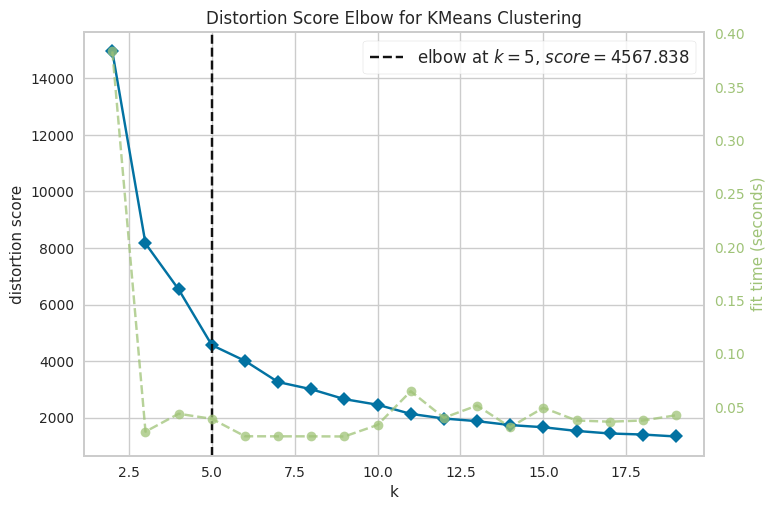

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [17]:
elbow_vis = KElbowVisualizer(KMeans(random_state=18), k=(2, 20))
elbow_vis.fit(X_train_scaled)
elbow_vis.show()

In [39]:
silhouette = silhouette_score(X_train_scaled.drop(columns=['cluster']), 
                               X_train_scaled['cluster'])
print(f'Silhouette Score: {silhouette:.4f}')

Silhouette Score: 0.4115


### Paso 2: Construye un K-Means

In [18]:
# Train K-Means only with scaled training
model = KMeans(n_clusters=6,
               random_state=18)
X_train_scaled['cluster'] = model.fit_predict(X_train_scaled)
X_train_scaled

,MedInc,Latitude,Longitude,cluster
19985,-0.176549,0.511873,-0.213158,2
11235,0.776105,-0.118734,0.142105,0
2271,0.009558,0.664908,-0.342105,5
8660,0.376037,-0.108179,0.028947,0
6250,-0.027764,-0.058047,0.136842,2
...,...,...,...,...
11288,0.775468,-0.121372,0.144737,0
11968,-0.740968,-0.068602,0.286842,2
5392,-0.159527,-0.058047,0.034211,2
860,0.994937,0.875989,-0.910526,1


In [19]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16508 entries, 19985 to 15799
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     16508 non-null  float64
 1   Latitude   16508 non-null  float64
 2   Longitude  16508 non-null  float64
 3   cluster    16508 non-null  int32  
dtypes: float64(3), int32(1)
memory usage: 580.4 KB


Text(0.5, 0, 'Cluster')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

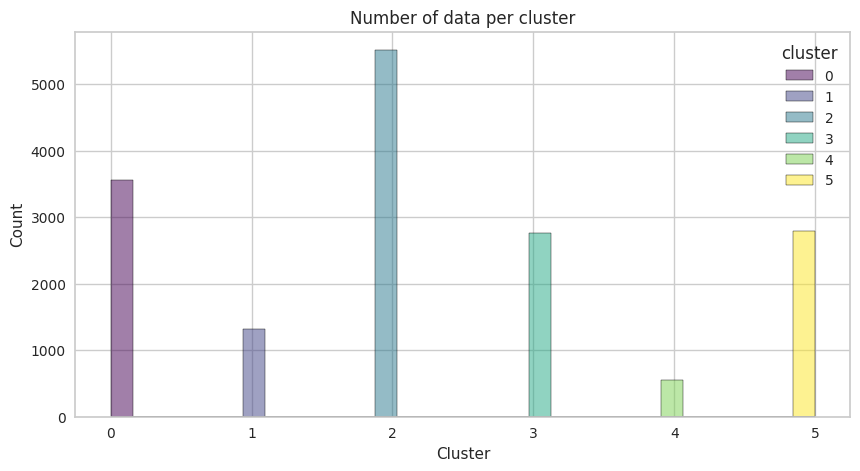

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(data=X_train_scaled, x='cluster', hue='cluster', palette='viridis')
plt.title('Number of data per cluster')
plt.xlabel('Cluster')

In [21]:
X_train_scaled['cluster'].value_counts()

cluster
2    5515
0    3561
5    2796
3    2765
1    1323
4     548
Name: count, dtype: int64

> Observaciones:
>
> - Los clusters 2 y 0 representan la mayor parte de las viviendas del conjunto de datos.
> - El cluster 4 es claramente el más pequeño (apenas 548 observaciones).

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

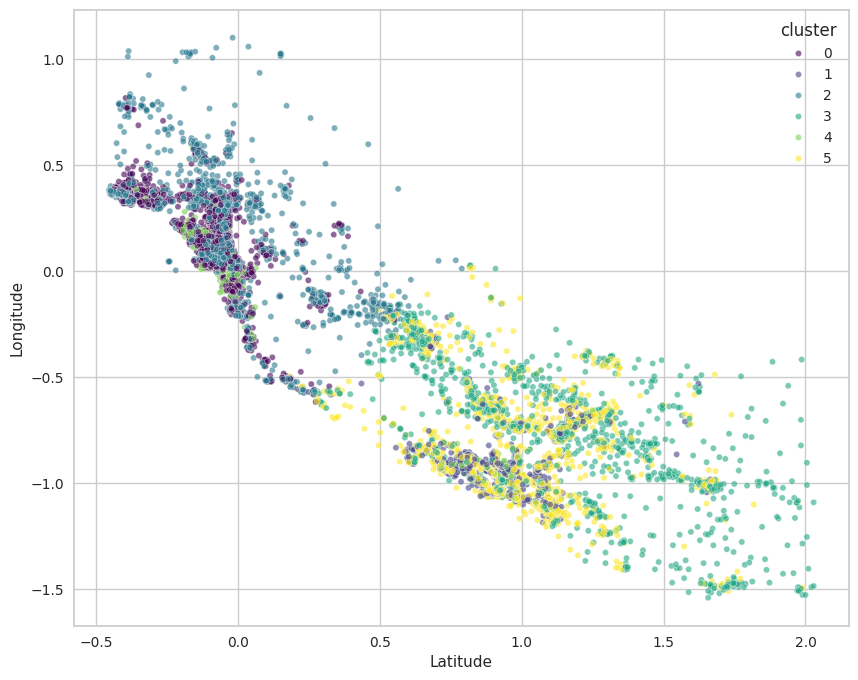

In [22]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=X_train_scaled, x='Latitude', y='Longitude', hue='cluster', palette='viridis', alpha=0.6, s=20)
plt.show()

In [23]:
fig = px.scatter_3d(X_train_scaled,
                    x='Latitude',
                    y='Longitude',
                    z='MedInc',
                    color='cluster',
                    width=900,
                    height=600)
fig.show()

In [24]:
X_train_scaled.groupby('cluster').mean()

,MedInc,Latitude,Longitude
cluster,,,
0,0.739704,-0.103433,0.126387
1,1.174649,0.900458,-0.907151
2,-0.377444,-0.074603,0.136228
3,-0.592695,1.046269,-0.796696
4,3.004753,0.162991,-0.182957
5,0.164579,0.945507,-0.858344


> Observaciones:
> - 
> - Cluster 4 tiene un ingreso medio muy alto comparado con la mediana.
> - Clusters 3 y 2 tienen ingresos bajos (valores negativos).
> - Clusters 0, 1 y 5 son moderados a altos.

In [43]:
# Centroids at original scale
centroids_scaled = model.cluster_centers_
centroids_original = robust_scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=['MedInc', 'Latitude', 'Longitude'],
    index=[f'Cluster {i}' for i in range(6)]
)
print("Centroides en escala original:")
centroids_df

Centroides en escala original:


,MedInc,Latitude,Longitude
Cluster 0,5.160489,33.867702,-118.019066
Cluster 1,6.114050,37.672736,-121.947173
Cluster 2,2.705287,33.977745,-117.983106
Cluster 3,2.230142,38.226115,-121.527426
Cluster 4,10.135017,34.877737,-119.195237
Cluster 5,3.894182,37.843678,-121.762219


In [25]:
# Convert values 0–5 into categories
X_train_scaled['cluster'] = X_train_scaled['cluster'].astype('category')

In [26]:
X_train_scaled['cluster']

19985    2
11235    0
2271     5
8660     0
6250     2
        ..
11288    0
11968    2
5392     2
860      1
15799    3
Name: cluster, Length: 16508, dtype: category
Categories (6, int32): [0, 1, 2, 3, 4, 5]

In [27]:
X_train_scaled['cluster'].unique()

[2, 0, 5, 3, 1, 4]
Categories (6, int32): [0, 1, 2, 3, 4, 5]

### Paso 3: Predice con el conjunto de test

In [28]:
X_test_scaled['cluster'] = model.predict(X_test_scaled)
X_test_scaled['cluster'] = X_test_scaled['cluster'].astype("category")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

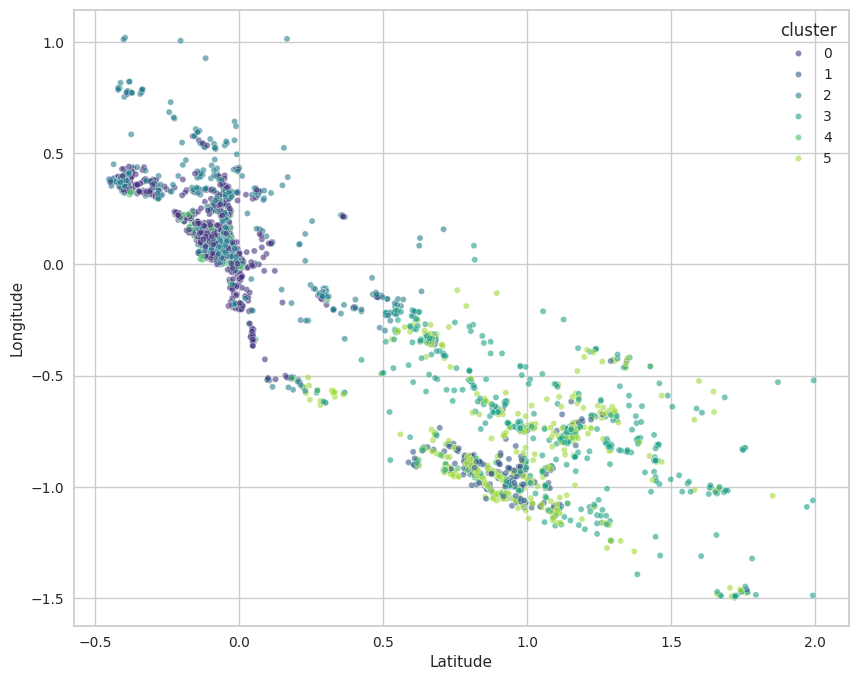

In [29]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=X_test_scaled, x='Latitude', y='Longitude', hue='cluster', palette='viridis', alpha=0.6, s=20)
plt.show()

> Observaciones:
>
> Aunque hay agrupaciones claras, también se observa un solapamiento considerable entre diferentes clusters en varias regiones. Esto es esperable, ya que el clustering no solo se basa en `Latitude` y `Longitude`, sino también en `MedInc`. 

### Paso 4: Entrena un modelo de clasificación supervisada

In [30]:
model_random_forest = RandomForestClassifier(n_estimators=200,
                                             random_state=42)

In [31]:
model_random_forest.fit(X_train_scaled.drop(columns=['cluster']), 
                                            X_train_scaled['cluster'])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred = model_random_forest.predict(X_test_scaled.drop(columns=['cluster']))

In [33]:
accuracy_score(X_test_scaled['cluster'], y_pred)

0.9951538647928277

> El modelo RandomForestClassifier alcanza una precisión del 99.5% al predecir el cluster asignado por K-Means. Esto demuestra que, una vez que K-Means ha agrupado las casas, un modelo supervisado puede aprender a replicar esa agrupación de manera casi perfecta usando las mismas características de entrada (MedInc, Latitude, Longitude).


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

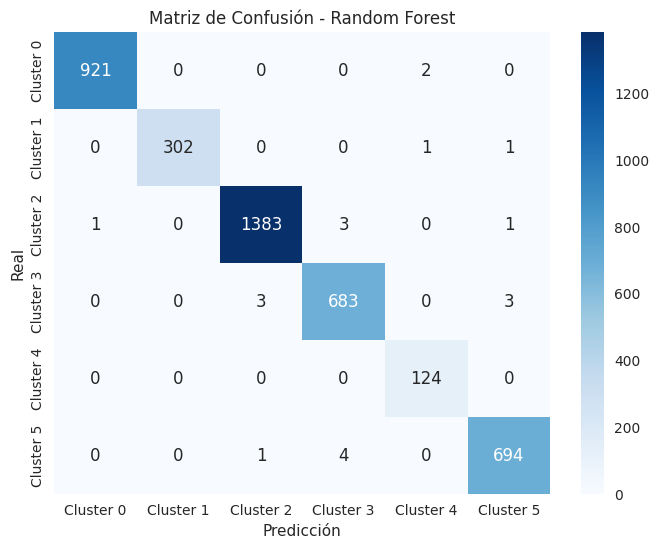

In [41]:
cm = confusion_matrix(X_test_scaled['cluster'], y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(6)],
            yticklabels=[f'Cluster {i}' for i in range(6)])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [42]:
print(classification_report(X_test_scaled['cluster'], y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       923
           1       1.00      0.99      1.00       304
           2       1.00      1.00      1.00      1388
           3       0.99      0.99      0.99       689
           4       0.98      1.00      0.99       124
           5       0.99      0.99      0.99       699

    accuracy                           1.00      4127
   macro avg       0.99      1.00      0.99      4127
weighted avg       1.00      1.00      1.00      4127



### Paso 5: Guarda los modelos

In [36]:
# Guardar K-Means
with open('/workspaces/inetke-machine-learning/models/kmeans_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Guardar Scaler
with open('/workspaces/inetke-machine-learning/models/robust_scaler.pkl', 'wb') as file:
    pickle.dump(robust_scaler, file)

# Guardar RandomForest
with open('/workspaces/inetke-machine-learning/models/random_forest_clusters.pkl', 'wb') as file:
    pickle.dump(model_random_forest, file)